## Exploratory Data Analaysis
- Analyzing important features which help to predict international game results

In [56]:
import pandas as pd
from pathlib import Path
import sys

In [57]:
results_path = Path("../data/results.csv")
results = pd.read_csv(results_path)
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


### Cleaning Data
- Only need results from past 15 years. 
- Only need results where either the home_team or away_team is a team in the current world cup

In [58]:
teams = [
    "Mexico", "South Africa", "South Korea", "Czech Republic",
    "Canada", "Switzerland", "Qatar", "Bosnia and Herzegovina",
    "Brazil", "Morocco", "Haiti", "Scotland",
    "United States", "Paraguay", "Australia", "Turkey",
    "Germany", "Curaçao", "Ivory Coast", "Ecuador",
    "Netherlands", "Japan", "Sweden", "Tunisia",
    "Belgium", "Egypt", "Iran", "New Zealand",
    "Spain", "Cape Verde", "Saudi Arabia", "Uruguay",
    "France", "Senegal", "Norway", "Iraq",
    "Argentina", "Algeria", "Austria", "Jordan",
    "Portugal", "DR Congo", "Uzbekistan", "Colombia",
    "England", "Croatia", "Ghana", "Panama",
]

results = results[(results["home_team"].isin(teams) | results["away_team"].isin(teams)) & (results["date"] >= "2011-01-01")]
results.describe()

,home_score,away_score
count,6941.000000,6941.000000
mean,1.608990,1.080536
std,1.588449,1.258858
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,15.000000,11.000000


In [59]:
missing = set(teams) - set(results["home_team"]).union(set(results["away_team"]))
print(missing)

set()


In [60]:
results.info()

<class 'pandas.DataFrame'>
Index: 7011 entries, 34451 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        7011 non-null   str    
 1   home_team   7011 non-null   str    
 2   away_team   7011 non-null   str    
 3   home_score  6941 non-null   float64
 4   away_score  6941 non-null   float64
 5   tournament  7011 non-null   str    
 6   city        7011 non-null   str    
 7   country     7011 non-null   str    
 8   neutral     7011 non-null   bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 499.8 KB


In [61]:
results.isnull().sum()

date           0
home_team      0
away_team      0
home_score    70
away_score    70
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [62]:
results[results["home_score"].isnull() | results["away_score"].isnull()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49407,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49408,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49409,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
49410,2026-06-13,Brazil,Morocco,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49411,2026-06-13,Haiti,Scotland,NaN,NaN,FIFA World Cup,Foxborough,United States,True
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [63]:
results = results.dropna(subset=["home_score", "away_score"])

In [64]:
results["result"] = results.apply(
    lambda x: "home_win" if x["home_score"] > x["away_score"]
    else "away_win" if x["home_score"] < x["away_score"]
    else "draw", axis=1
)
results["result"].value_counts(normalize=True)  # % of each outcome

result
home_win    0.482351
away_win    0.285838
draw        0.231811
Name: proportion, dtype: float64

In [66]:
results.groupby("neutral")["result"].value_counts(normalize=True)


neutral  result  
False    home_win    0.510461
         away_win    0.269551
         draw        0.219988
True     home_win    0.413776
         away_win    0.325570
         draw        0.260654
Name: proportion, dtype: float64

In [67]:
# Wins per team
home_wins = results[results["result"] == "home_win"].groupby("home_team").size()
away_wins = results[results["result"] == "away_win"].groupby("away_team").size()

# Goals scored per team
home_goals = results.groupby("home_team")["home_score"].mean()
away_goals = results.groupby("away_team")["away_score"].mean()

In [68]:
home_wins.sort_values(ascending=False).head(10)

home_team
United States    108
Mexico            91
Morocco           88
Egypt             86
Japan             86
Argentina         85
Brazil            82
France            81
Qatar             79
South Korea       79
dtype: int64

In [69]:
away_wins.sort_values(ascending=False).head(10)

away_team
Spain       54
Mexico      54
Germany     48
Brazil      48
Portugal    47
Belgium     47
France      46
Iran        46
Colombia    45
Algeria     45
dtype: int64

In [70]:
results["tournament"].value_counts()
# Are World Cup games lower scoring than friendlies?
results["total_goals"] = results["home_score"] + results["away_score"]
results.groupby("tournament")["total_goals"].mean().sort_values(ascending=False)

tournament
CONCACAF Nations League qualification    5.333333
Navruz Cup                               5.000000
Gold Cup qualification                   4.666667
CAFA Nations Cup                         4.166667
ABCS Tournament                          4.125000
CFU Caribbean Cup qualification          3.576923
Unity Cup                                3.500000
Confederations Cup                       3.400000
CONCACAF Nations League                  3.145833
UEFA Euro qualification                  3.105832
EAFF Championship                        3.033333
CONMEBOL–UEFA Cup of Champions           3.000000
Oceania Nations Cup                      2.928571
Nile Basin Tournament                    2.888889
Kirin Cup                                2.857143
CFU Caribbean Cup                        2.846154
UEFA Nations League                      2.833333
Gold Cup                                 2.827160
FIFA World Cup qualification             2.812432
FIFA Series                            

<Axes: xlabel='year'>

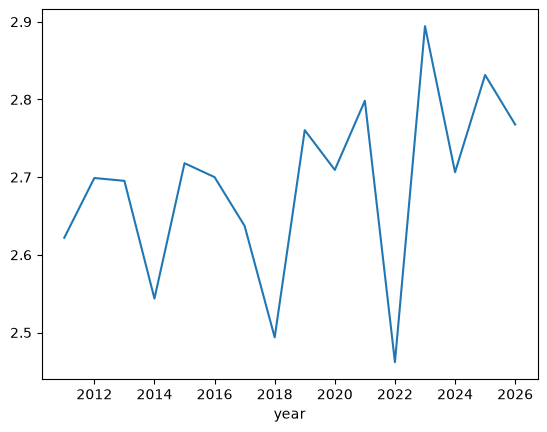

In [71]:
results["date"] = pd.to_datetime(results["date"])
results["year"] = results["date"].dt.year
results.groupby("year")["total_goals"].mean().plot()

### Finalizing dataset
- For the worldcup, home and away teams don't make a difference, so relabel as team A vs team B

In [72]:
results = results.rename(columns={
    "home_team": "team_a",
    "away_team": "team_b",
    "home_score": "team_a_score",
    "away_score": "team_b_score",
})

# Add result column
def get_result(row):
    if row["team_a_score"] > row["team_b_score"]:
        return 0  # team_a wins
    elif row["team_a_score"] < row["team_b_score"]:
        return 2  # team_b wins
    else:
        return 1  # draw

results["result"] = results.apply(get_result, axis=1)

In [73]:
results = results.drop(columns=["date", "tournament", "city", "country", "total_goals"])

In [77]:
results.to_csv("../data/cleaned_results.csv", index=False)